# Analyse de données et Gradient Boosting

Ce notebook démontre l'utilisation de XGBoost sur un jeu de données synthétique.

## Installation des dépendances nécessaires

In [1]:

!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install xgboost
!pip install graphviz



[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [2]:

# Importation des librairies nécessaires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb


## Génération d'un jeu de données synthétique

In [3]:

# Création d'un dataset synthétique pour la classification
from sklearn.datasets import make_classification

# Génération des données
X, y = make_classification(
    n_samples=1000, 
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_classes=2,
    random_state=42
)

# Conversion en DataFrame pour une meilleure visualisation
df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
df['target'] = y

# Affichage des premières lignes
print("Aperçu du jeu de données:")
df.head()


Aperçu du jeu de données:


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
0,1.470848,-0.360450,-0.591602,-0.728228,0.941690,1.065964,0.017832,-0.596184,1.840712,-1.497093,...,-0.603968,2.899256,0.037567,-1.249523,0.257963,0.416628,1.408208,-1.838041,-0.833142,1
1,4.513369,-2.227103,-1.140747,2.018263,-2.238358,-0.497370,0.714550,0.938883,-2.395169,0.159837,...,1.461499,3.954171,0.309054,0.538184,-7.157865,-4.532216,-0.081800,-9.325362,0.574386,1
2,-2.355643,2.218601,-1.603269,0.873394,0.401483,0.717264,-0.859399,-1.042190,-2.175965,0.980231,...,0.544434,-2.466258,-0.470256,0.073018,-2.203531,-2.299263,-1.742761,-0.271579,-0.359285,0
3,-1.596198,-0.857427,1.772434,-0.639361,1.419409,-0.438525,0.281949,2.345145,1.006230,0.389135,...,-1.025051,-2.422975,1.579807,-0.300713,4.267120,2.893775,1.236697,6.034785,-0.045711,0
4,2.840049,-2.489600,-0.844902,-1.594362,-4.688517,0.459637,0.913607,-1.143505,1.263937,-2.040928,...,4.176424,1.341742,0.133565,1.743819,1.531188,2.269808,0.053489,-3.151109,1.603702,0


## Exploration des données

In [4]:

# Statistiques descriptives
print("Statistiques descriptives:")
df.describe()


Statistiques descriptives:


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.053827,0.018832,-0.480995,0.020933,0.336366,-0.002051,0.023751,-0.518758,0.318615,-0.477339,...,0.461165,0.286774,0.025932,-0.011629,0.502478,0.635379,0.498664,0.142797,0.013416,0.503000
std,2.130360,2.095132,1.879645,2.011018,3.542104,0.988013,1.011611,2.104034,2.955660,2.050913,...,1.926458,3.659004,0.990602,2.174453,3.681639,2.185076,2.010160,3.558016,1.017575,0.500241
min,-6.865339,-7.030162,-6.227178,-6.184692,-11.421566,-3.250333,-3.375579,-7.771723,-9.055589,-8.705917,...,-5.708949,-14.060306,-3.329504,-6.817417,-13.717683,-6.925613,-7.455322,-15.224345,-3.094289,0.000000
25%,-1.347721,-1.360239,-1.762233,-1.272814,-1.861818,-0.670887,-0.659505,-1.842647,-1.612948,-1.857157,...,-0.656732,-2.031074,-0.590123,-1.490351,-1.983980,-0.820619,-0.855006,-2.243592,-0.659659,0.000000
50%,0.092325,0.125624,-0.561960,0.138819,0.302071,0.015847,0.001733,-0.537322,0.532299,-0.423465,...,0.571637,0.271154,0.043274,-0.000744,0.640327,0.679993,0.465423,-0.011351,0.006404,1.000000
75%,1.517749,1.410062,0.730689,1.459672,2.679576,0.626378,0.706289,0.823834,2.394011,1.003092,...,1.808735,2.687756,0.650973,1.394460,2.895446,2.148864,1.857764,2.436021,0.718129,1.000000
max,7.021821,8.237993,6.903293,6.832418,11.988010,3.287761,3.428910,6.489389,8.443451,5.101133,...,7.501492,13.935539,3.285724,7.889919,12.694487,6.390253,6.365330,13.268480,3.377768,1.000000


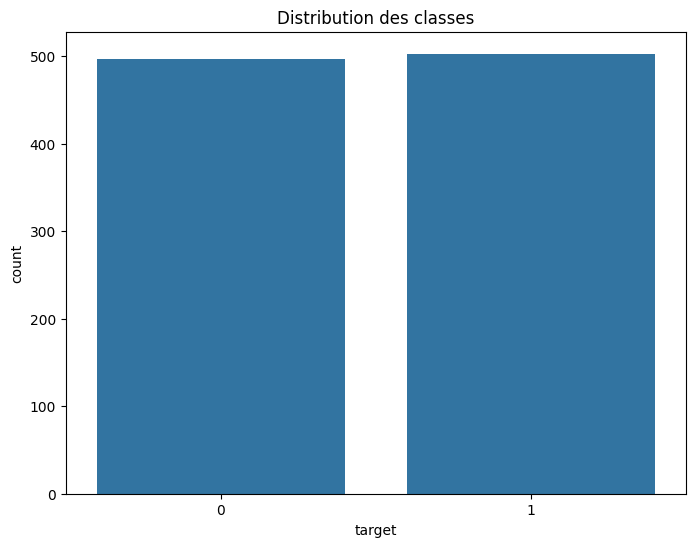

In [5]:

# Visualisation de la distribution des classes
plt.figure(figsize=(8, 6))
sns.countplot(x='target', data=df)
plt.title('Distribution des classes')
plt.show()


<Figure size 1200x1000 with 0 Axes>

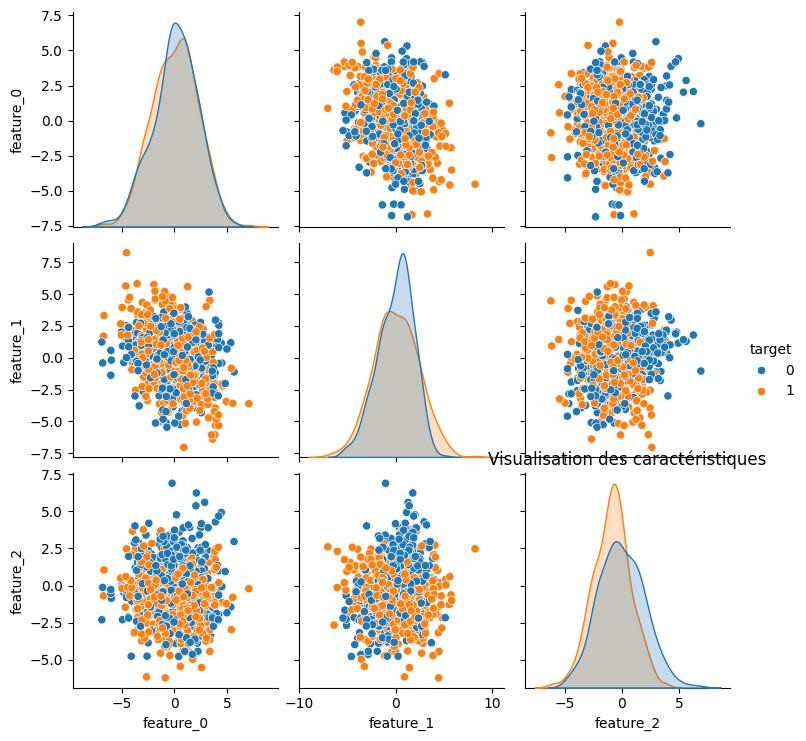

In [6]:

# Visualisation de quelques caractéristiques
plt.figure(figsize=(12, 10))
sns.pairplot(df[['feature_0', 'feature_1', 'feature_2', 'target']], hue='target')
plt.title('Visualisation des caractéristiques')
plt.show()


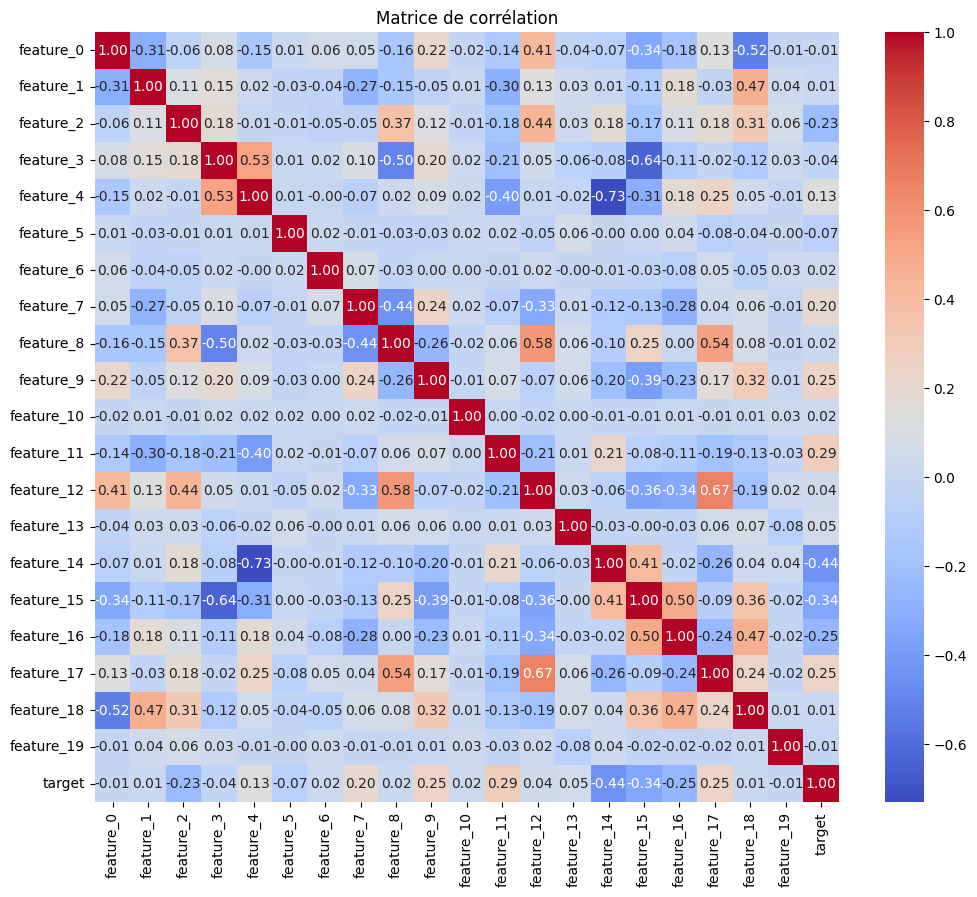

In [7]:

# Matrice de corrélation
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de corrélation')
plt.show()


## Préparation des données pour l'apprentissage

In [8]:

# Division en ensembles d'entraînement et de test
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de l'ensemble d'entraînement: {X_train.shape}")
print(f"Taille de l'ensemble de test: {X_test.shape}")


Taille de l'ensemble d'entraînement: (800, 20)
Taille de l'ensemble de test: (200, 20)


## Entraînement du modèle Gradient Boosting (XGBoost)

In [9]:

# Configuration du modèle XGBoost
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    random_state=42
)

# Entraînement du modèle
model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

## Évaluation du modèle

Précision du modèle: 0.9100
Rapport de classification:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       102
           1       0.89      0.93      0.91        98

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200



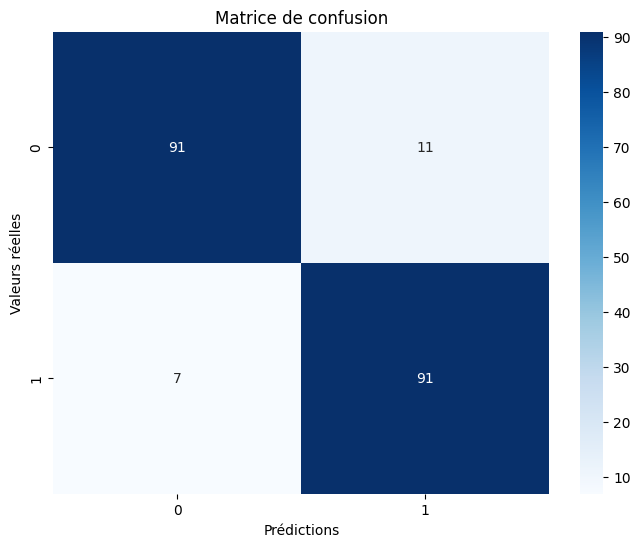

In [10]:

# Prédictions sur l'ensemble de test
y_pred = model.predict(X_test)

# Évaluation des performances
accuracy = accuracy_score(y_test, y_pred)
print(f"Précision du modèle: {accuracy:.4f}")

# Rapport de classification détaillé
print("Rapport de classification:")
print(classification_report(y_test, y_pred))

# Matrice de confusion
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédictions')
plt.ylabel('Valeurs réelles')
plt.title('Matrice de confusion')
plt.show()


## Analyse de l'importance des caractéristiques

<Figure size 1200x600 with 0 Axes>

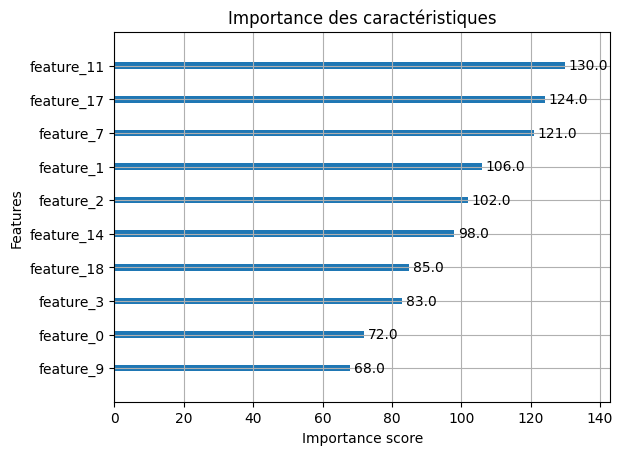

In [11]:

# Visualisation de l'importance des caractéristiques
plt.figure(figsize=(12, 6))
xgb.plot_importance(model, max_num_features=10)
plt.title('Importance des caractéristiques')
plt.show()


/Users/eliottvalette/Library/Mobile Documents/com~apple~CloudDocs/Documents/Codage /NoteBook Maker/.venv/lib/python3.10/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 2000x1000 with 0 Axes>

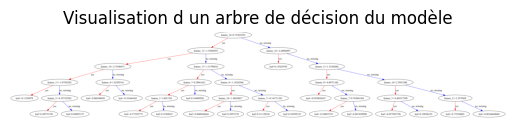

In [12]:

# Visualisation d un arbre de décision du modèle
plt.figure(figsize=(20, 10))
xgb.plot_tree(model, num_trees=0)
plt.title('Visualisation d un arbre de décision du modèle')
plt.show()


## Conclusion

Dans ce notebook, nous avons créé un jeu de données synthétique et entraîné un modèle de classification avec XGBoost. Nous avons pu visualiser les performances du modèle et identifier les caractéristiques les plus importantes pour la prédiction.